# 🚀 Advanced Matplotlib Practice Notebook

This notebook contains **progressive practice exercises** (intermediate → advanced) to deepen your Matplotlib skills. Each exercise has a description, starter code, and hints. Try to solve the problems in the provided code cells.

**How to use:** Run the first cell (imports & helpers). For each exercise, write your solution in the code cell below the prompt.


In [3]:

# Run this cell first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optional: for 3D plotting
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Make plots appear inline in Jupyter
%matplotlib inline

# Set a default figure size for convenience
plt.rcParams['figure.figsize'] = (8, 5)
print('Libraries loaded. Ready to practice!')


Libraries loaded. Ready to practice!


## 1. Line plot — advanced styling

Plot x = np.linspace(0, 2*np.pi, 100). Plot sin(x) and cos(x) with different linestyles, markers every 10 points, and a legend. Add grid and a title that shows the functions' formulas.

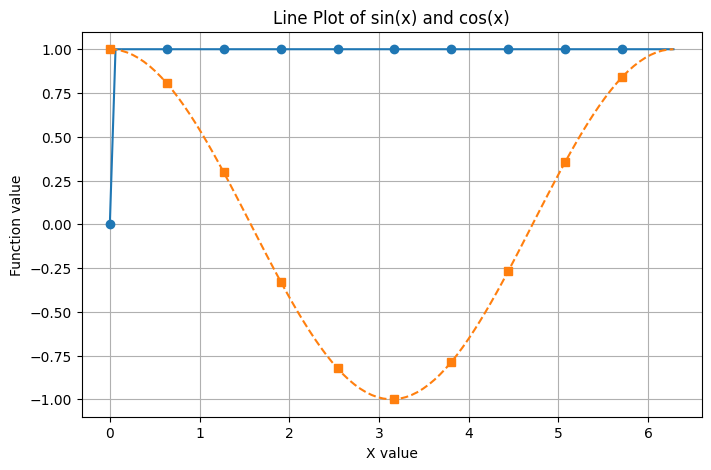

In [4]:
# Data
x = np.linspace(0, 2*np.pi, 100)
y_sin = np.sign(x)
y_cos = np.cos(x)

plt.figure()

plt.plot(x, y_sin, linestyle='-', marker='o', markevery=10, label='sin(x)')
plt.plot(x, y_cos, linestyle='--', marker='s', markevery=10, label='cos(x)')

plt.title("Line Plot of sin(x) and cos(x)")
plt.ylabel("Function value")
plt.xlabel("X value")
plt.grid((2,2))

plt.show()

### Hint
- Think about using `ax.twinx()`, `plt.subplots()` with `gridspec_kw`, `np.meshgrid`, and `plt.imshow`.
- Use `ax.annotate(...)` for annotation tasks.
- For grouped bars: compute bar positions with `np.arange()` and offsets.

# When you finish, run the cell above to display your plot.

## 2. Multiple subplots with GridSpec

Create a 2x2 layout using GridSpec. Top-left: line plot of sin(x). Top-right: scatter of random points. Bottom: a bar chart spanning both bottom cells.

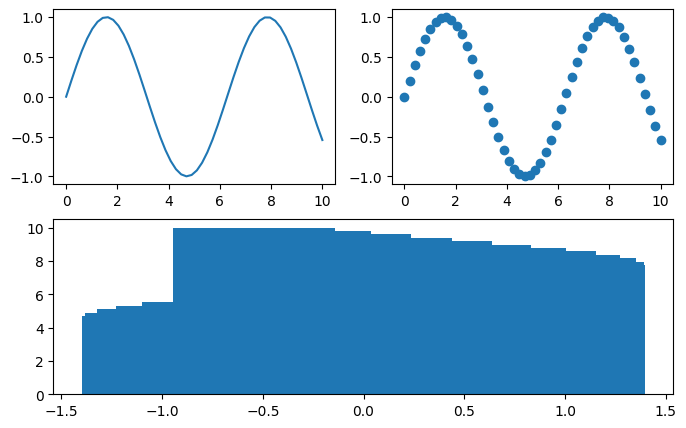

In [5]:
# Data
x = np.linspace(0, 10, 50)
y = np.sin(x)

fig = plt.figure()

gs = fig.add_gridspec(2,2)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,:])

ax1.plot(x, y)
ax2.scatter(x, y)
ax3.bar(y,x)

plt.show()

### Hint
- Think about using `ax.twinx()`, `plt.subplots()` with `gridspec_kw`, `np.meshgrid`, and `plt.imshow`.
- Use `ax.annotate(...)` for annotation tasks.
- For grouped bars: compute bar positions with `np.arange()` and offsets.

# When you finish, run the cell above to display your plot.

## 3. Twin axes (different scales)

Plot x vs x^2 on the left y-axis and x vs exp(x)/1000 on the right y-axis using twin axes. Label both y-axes and use different colors.

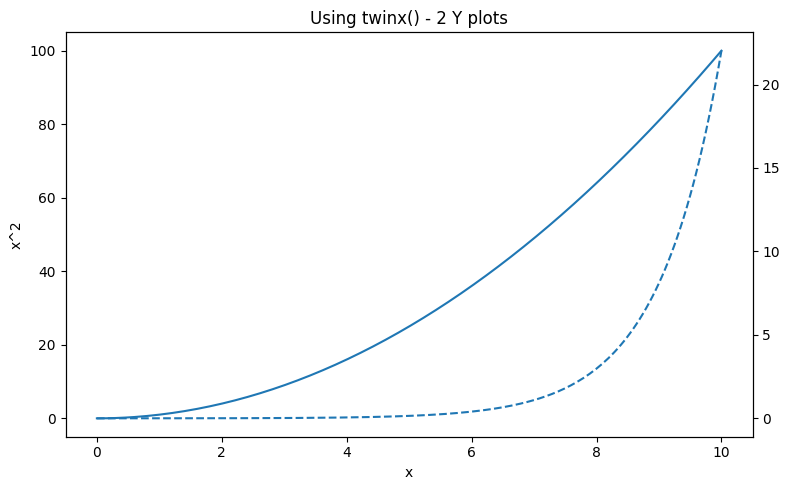

In [6]:
x = np.linspace(0, 10, 200)

fig, ax = plt.subplots()

ax.plot(x, x**2, label="x^2") 
ax.set_xlabel("x")
ax.set_ylabel('x^2')

ax2 = ax.twinx()

ax2.plot(x, np.exp(x)/1000, linestyle='--', label='exp(x)/1000')
plt.title("Using twinx() - 2 Y plots")
plt.tight_layout()

plt.show()

### Hint
- Think about using `ax.twinx()`, `plt.subplots()` with `gridspec_kw`, `np.meshgrid`, and `plt.imshow`.
- Use `ax.annotate(...)` for annotation tasks.
- For grouped bars: compute bar positions with `np.arange()` and offsets.

# When you finish, run the cell above to display your plot.

## 4. Scatter with colormap + colorbar

Create 300 random points for x and y, color them by their distance from origin, and add a colorbar. Use marker size variation too.

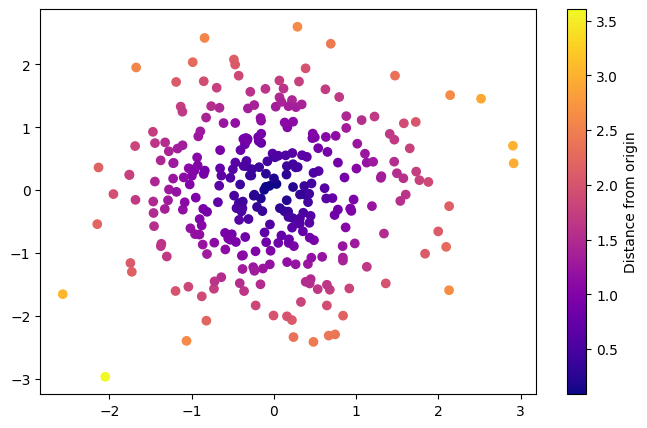

In [7]:
rng = np.random.default_rng(42)
x = rng.normal(size=300)
y = rng.normal(size=300)

colours = np.sqrt(x**2 + y**2)

plt.figure()

scatter = plt.scatter(x,y,c=colours, cmap='plasma')

plt.colorbar(scatter, label='Distance from origin')

plt.show()


### Hint
- Think about using `ax.twinx()`, `plt.subplots()` with `gridspec_kw`, `np.meshgrid`, and `plt.imshow`.
- Use `ax.annotate(...)` for annotation tasks.
- For grouped bars: compute bar positions with `np.arange()` and offsets.

# When you finish, run the cell above to display your plot.

## 5. Histogram: density, cumulative, and overlay

Generate 1000 samples from a normal distribution and plot both a histogram (density=True) and the corresponding KDE-like smooth curve (you can use np.histogram to compute bin centers). Also produce a cumulative histogram on a twin axis.

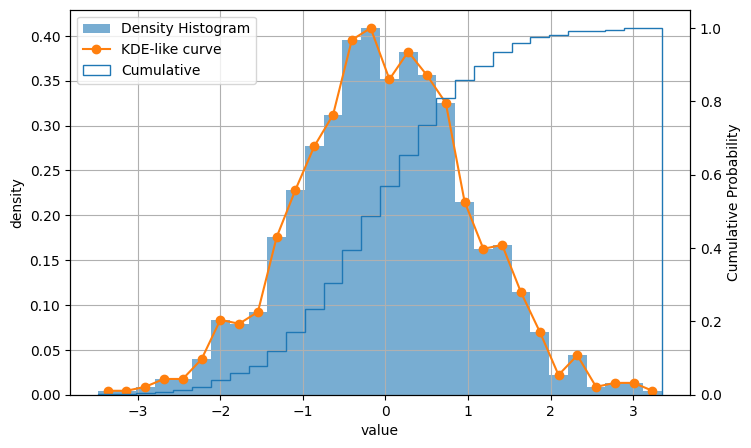

In [8]:
data = np.random.normal(loc=0, scale=1, size=1000)

fig, ax = plt.subplots()

count, bins, patches = ax.hist(data, bins=30, density=True, alpha=0.6, label='Density Histogram')

hist_val, bin_edges = np.histogram(data, bins=30, density=True)
bin_cntr = 0.5 * (bin_edges[:-1] + bin_edges[1:])

ax.plot(bin_cntr, hist_val, marker='o', linestyle='-', label='KDE-like curve')

ax.set_xlabel('value')
ax.set_ylabel('density')
ax.grid(True)

ax1 = ax.twinx()

ax1.hist(data, bins=30, density=True, cumulative=True, histtype='step', linewidth=1, label='Cumulative')

ax1.set_ylabel("Cumulative Probability")

lines1, label1 = ax.get_legend_handles_labels()
lines2, label2 = ax1.get_legend_handles_labels()

ax.legend(lines1 + lines2, label1 + label2, loc='upper left')

# plt.legend()
plt.show()


### Hint
- Think about using `ax.twinx()`, `plt.subplots()` with `gridspec_kw`, `np.meshgrid`, and `plt.imshow`.
- Use `ax.annotate(...)` for annotation tasks.
- For grouped bars: compute bar positions with `np.arange()` and offsets.

# When you finish, run the cell above to display your plot.

## 6. Bar chart — grouped bars with error bars

Create grouped bars for 3 categories over 4 groups (use random values). Add error bars and annotated bar values on top of bars.

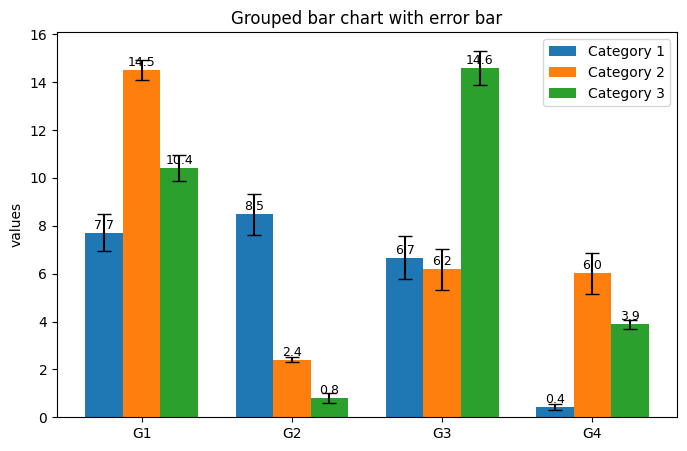

In [9]:
groups = ['G1', 'G2', 'G3', 'G4']
cat_values = np.abs(np.random.randn(3, 4)) * 10
errors = np.random.rand(3,4)

n_group = len(groups)

x = np.arange(n_group)

width = 0.25

fig, ax = plt.subplots()

for i in range(3):
    bars = ax.bar(
        x+i*width, 
        cat_values[i],
        width=width,
        yerr=errors[i],
        capsize=5,
        label=f"Category {i+1}"
    )

    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.1f}",
            xy=(bar.get_x() + bar.get_width()/2, height),
            xytext=(0,3),
            textcoords='offset points',
            ha='center',
            fontsize=9
        )
ax.set_xticks(x + width)
ax.set_xticklabels(groups)
ax.set_ylabel('values')
ax.set_title("Grouped bar chart with error bar")
ax.legend()

plt.show()

### Hint
- Think about using `ax.twinx()`, `plt.subplots()` with `gridspec_kw`, `np.meshgrid`, and `plt.imshow`.
- Use `ax.annotate(...)` for annotation tasks.
- For grouped bars: compute bar positions with `np.arange()` and offsets.

# When you finish, run the cell above to display your plot.

## 7. Stacked bar chart and percentage annotation

Create a stacked bar chart from a (4 x 3) dataset and annotate each segment with its percentage contribution within the bar.

In [22]:
data = np.abs(np.random.randn(4,3))
labels = ['A','B','C']
index = np.arange(4)

### Hint
- Think about using `ax.twinx()`, `plt.subplots()` with `gridspec_kw`, `np.meshgrid`, and `plt.imshow`.
- Use `ax.annotate(...)` for annotation tasks.
- For grouped bars: compute bar positions with `np.arange()` and offsets.

# When you finish, run the cell above to display your plot.

## 8. Boxplot and violin plot comparison

Generate 4 groups of data with different distributions and plot them side-by-side using boxplot and violinplot for comparison.

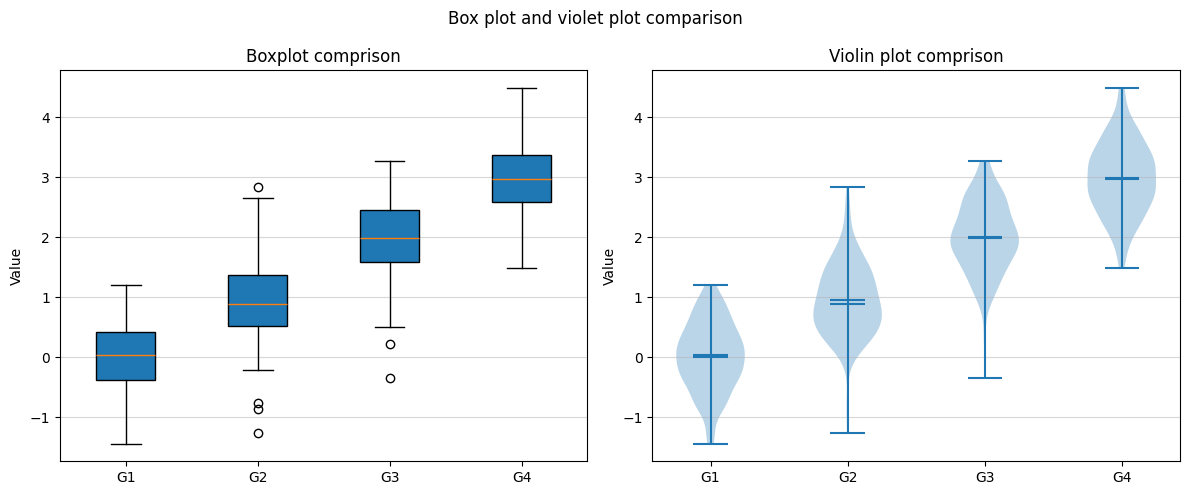

In [29]:
rng = np.random.default_rng(0)
groups = [rng.normal(loc=i, scale=0.6, size=200) for i in range(4)]
data = []

for i in groups:
    data.append(i)


fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].boxplot(data, patch_artist=True)
ax[0].set_title("Boxplot comprison")
ax[0].set_xticklabels(['G1', 'G2', 'G3', 'G4'])
ax[0].set_ylabel("Value")
ax[0].grid(True, axis='y', alpha=0.5)

ax[1].violinplot(data, showmeans=True, showmedians=True)
ax[1].set_title("Violin plot comprison")
ax[1].set_xticks(range(1,5))
ax[1].set_xticklabels(['G1', 'G2', 'G3', 'G4'])
ax[1].set_ylabel("Value")
ax[1].grid(True, axis='y', alpha=0.5)
plt.suptitle("Box plot and violet plot comparison")

plt.tight_layout()
plt.show()


### Hint
- Think about using `ax.twinx()`, `plt.subplots()` with `gridspec_kw`, `np.meshgrid`, and `plt.imshow`.
- Use `ax.annotate(...)` for annotation tasks.
- For grouped bars: compute bar positions with `np.arange()` and offsets.

# When you finish, run the cell above to display your plot.

## 9. Heatmap from 2D array with annotations

Create a 10x10 matrix with a smooth gradient (e.g., outer product or Gaussian) and plot it using imshow. Add value annotations on each cell (rounded to 2 decimals).

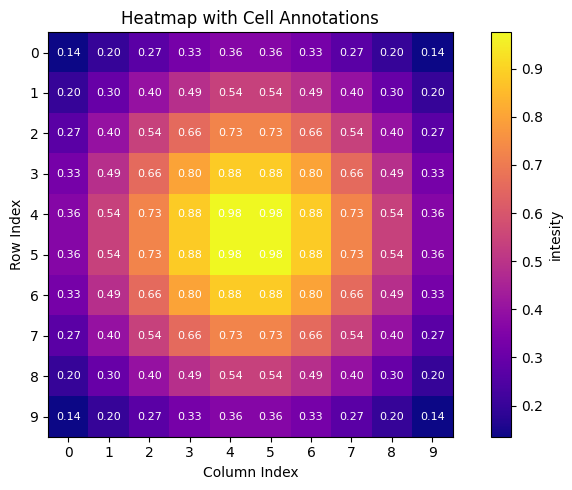

In [35]:
x = np.linspace(-1,1,10)
X, Y = np.meshgrid(x, x)
Z = np.exp(-(X**2 + Y**2))

fig, ax = plt.subplots()

im = ax.imshow(Z, cmap="plasma")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("intesity")

for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        ax.text(
            j, i,
            f"{Z[i, j]:.2f}",
            ha='center',
            va='center',
            color='white',
            fontsize=8
        )

ax.set_title("Heatmap with Cell Annotations")
ax.set_xticks(np.arange(10))
ax.set_yticks(np.arange(10))
ax.set_xlabel("Column Index")
ax.set_ylabel("Row Index")

plt.tight_layout()
plt.show()

### Hint
- Think about using `ax.twinx()`, `plt.subplots()` with `gridspec_kw`, `np.meshgrid`, and `plt.imshow`.
- Use `ax.annotate(...)` for annotation tasks.
- For grouped bars: compute bar positions with `np.arange()` and offsets.

# When you finish, run the cell above to display your plot.

## 10. Image display with imshow (use a random RGB array)

Create and show a 200x200 RGB image array with a circular gradient (use radius to set intensity). Turn off the axes.

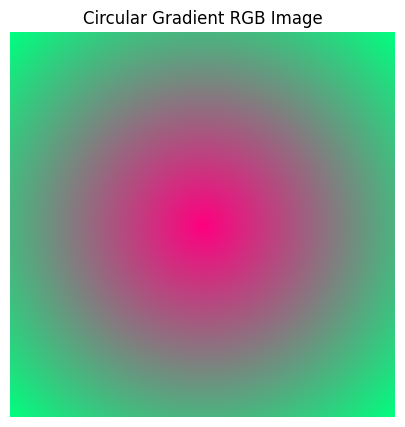

In [37]:
h, w = 200, 200
cy, cx = h//2, w//2
Y, X = np.ogrid[:h, :w]
R = np.sqrt((X-cx)**2 + (Y-cy)**2)
R = R/R.max()

red = 1 - R
green = R
blue = 0.5 * np.ones_like(R)

img = np.dstack((red,green,blue))

plt.imshow(img)
plt.axis('off')
plt.title("Circular Gradient RGB Image")
plt.show()

### Hint
- Think about using `ax.twinx()`, `plt.subplots()` with `gridspec_kw`, `np.meshgrid`, and `plt.imshow`.
- Use `ax.annotate(...)` for annotation tasks.
- For grouped bars: compute bar positions with `np.arange()` and offsets.

# When you finish, run the cell above to display your plot.

## 11. Polar plot: rose curve

Plot r = sin(5*theta) in polar coordinates. Make it visually pleasing with filled area and gridlines.

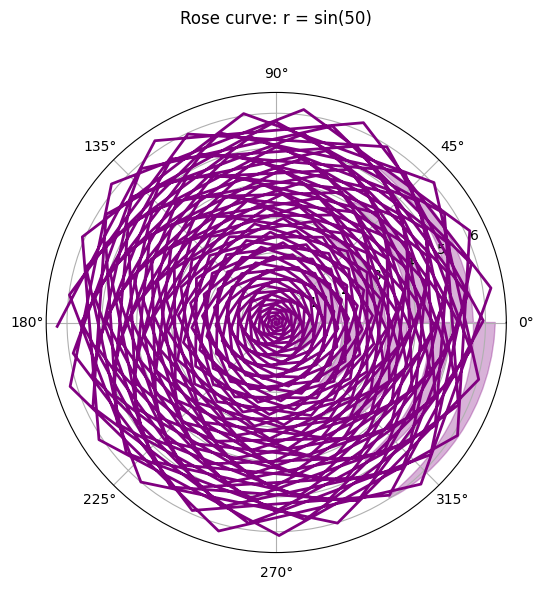

In [40]:
theta = np.linspace(0, 2*np.pi, 400)

r = np.sin(5 * theta)

fi, ax = plt.subplots(subplot_kw={"projection":"polar"}, figsize=(6,6))

ax.plot(theta, color='purple', linewidth=2)

ax.fill(r, theta, color='purple', alpha=0.3)

ax.set_title("Rose curve: r = sin(50)", pad=50)

plt.grid(True)
plt.tight_layout()
plt.show()

### Hint
- Think about using `ax.twinx()`, `plt.subplots()` with `gridspec_kw`, `np.meshgrid`, and `plt.imshow`.
- Use `ax.annotate(...)` for annotation tasks.
- For grouped bars: compute bar positions with `np.arange()` and offsets.

# When you finish, run the cell above to display your plot.

## 12. 3D surface plot

Create a 3D surface plot of z = sin(sqrt(x^2+y^2))/(sqrt(x^2+y^2)) over a grid. Add a colorbar from a ScalarMappable.

In [15]:
x = np.linspace(-6,6,80)
y = np.linspace(-6,6,80)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sin(R) / (R + 1e-6)

# Your code here


### Hint
- Think about using `ax.twinx()`, `plt.subplots()` with `gridspec_kw`, `np.meshgrid`, and `plt.imshow`.
- Use `ax.annotate(...)` for annotation tasks.
- For grouped bars: compute bar positions with `np.arange()` and offsets.

# When you finish, run the cell above to display your plot.

## 13. Errorbars + fill_between for uncertainty visualization

Plot y = sin(x) with shaded uncertainty (mean ± std) using fill_between. Also add errorbar points at sampled x locations.

In [16]:
x = np.linspace(0, 4*np.pi, 200)
mean = np.sin(x)
std = 0.2 + 0.2 * np.abs(np.sin(0.5*x))

# Your code here


### Hint
- Think about using `ax.twinx()`, `plt.subplots()` with `gridspec_kw`, `np.meshgrid`, and `plt.imshow`.
- Use `ax.annotate(...)` for annotation tasks.
- For grouped bars: compute bar positions with `np.arange()` and offsets.

# When you finish, run the cell above to display your plot.

## 14. Custom ticks, minor ticks and formatters

Plot any function and customize major ticks to be at every pi/2 and minor ticks at pi/8. Use formatted tick labels (e.g., 0, π/2, π).

In [17]:
x = np.linspace(0, 2*np.pi, 100)
y = np.sin(x)

# Your code here


### Hint
- Think about using `ax.twinx()`, `plt.subplots()` with `gridspec_kw`, `np.meshgrid`, and `plt.imshow`.
- Use `ax.annotate(...)` for annotation tasks.
- For grouped bars: compute bar positions with `np.arange()` and offsets.

# When you finish, run the cell above to display your plot.

## 15. Final challenge — Mini dashboard (combine 3 plots)

Using a pandas DataFrame with a time index of 60 days and columns 'A', 'B', 'C' (random walks), create a mini-dashboard: left large line plot (time series of A,B,C), top-right histogram of returns of A, bottom-right boxplot of returns grouped by weekday. Make the layout clean and annotated.

In [18]:
rng = np.random.default_rng(1)
dates = pd.date_range(end=pd.Timestamp.today(), periods=60)
vals = rng.normal(scale=0.02, size=(60,3))
prices = 100 + np.cumsum(vals, axis=0)
df = pd.DataFrame(prices, index=dates, columns=['A','B','C'])

# Your code here


### Hint
- Think about using `ax.twinx()`, `plt.subplots()` with `gridspec_kw`, `np.meshgrid`, and `plt.imshow`.
- Use `ax.annotate(...)` for annotation tasks.
- For grouped bars: compute bar positions with `np.arange()` and offsets.

# When you finish, run the cell above to display your plot.

----

## (Optional) Solutions

If you'd like, I can add a separate notebook with full solutions after you attempt these. Tell me when you're ready to see solutions—I'll create a solutions notebook so you can compare approaches.